In [65]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### LOADING AND UNDERSTANDING DATA

In [66]:
# Loading the dataset
ucd = pd.read_csv('used_cars_data.csv')

In [67]:
# Basic Data Understanding
print("Dataset Shape:", ucd.shape)
print("\nFirst Few Rows:")
display(ucd.head())
print("\nData Types:")
display(ucd.dtypes)
print("\nDataset Info:")
ucd.info()

Dataset Shape: (7253, 13)

First Few Rows:


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74



Data Types:


S.No.                  int64
Name                     str
Location                 str
Year                   int64
Kilometers_Driven      int64
Fuel_Type                str
Transmission             str
Owner_Type               str
Mileage                  str
Engine                   str
Power                    str
Seats                float64
Price                float64
dtype: object


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   str    
 2   Location           7253 non-null   str    
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   str    
 6   Transmission       7253 non-null   str    
 7   Owner_Type         7253 non-null   str    
 8   Mileage            7251 non-null   str    
 9   Engine             7207 non-null   str    
 10  Power              7207 non-null   str    
 11  Seats              7200 non-null   float64
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(3), str(8)
memory usage: 736.8 KB


In [68]:
# DESCRIPTIVE STATISTICS OF THE DATASET
ucd.describe()

,S.No.,Year,Kilometers_Driven,Seats,Price
count,7253.000000,7253.000000,7.253000e+03,7200.000000,6019.000000
mean,3626.000000,2013.365366,5.869906e+04,5.279722,9.479468
std,2093.905084,3.254421,8.442772e+04,0.811660,11.187917
min,0.000000,1996.000000,1.710000e+02,0.000000,0.440000
25%,1813.000000,2011.000000,3.400000e+04,5.000000,3.500000
50%,3626.000000,2014.000000,5.341600e+04,5.000000,5.640000
75%,5439.000000,2016.000000,7.300000e+04,5.000000,9.950000
max,7252.000000,2019.000000,6.500000e+06,10.000000,160.000000


### DATA CLEANING

In [ ]:
# FIXING DATA TYPES AND CORRECTING NAMES OF THE FEATURES
# Drop S.No. as it is not useful for analysis
ucd.drop(columns=['S.No.'], inplace=True)

# Remove 'kmpl' from Mileage column and convert to numeric
ucd['Mileage'] = ucd['Mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
ucd.rename(columns={'Mileage': 'Mileage_Kmpl'}, inplace=True)

# Remove 'CC' from Engine column and convert to numeric
ucd['Engine'] = ucd['Engine'].str.extract(r'(\d+\.?\d*)').astype(float)
ucd.rename(columns={'Engine': 'Engine_CC'}, inplace=True)

# Remove 'bhp' from Power column and convert to numeric
ucd['Power'] = ucd['Power'].str.extract(r'(\d+\.?\d*)').astype(float)
ucd.rename(columns={'Power': 'Power_bhp'}, inplace=True)

# Convert Price from Lakh to actual rupees (multiply by 100,000)
ucd['Price'] = ucd['Price'] * 100000

# Extract Brand from Name
ucd['Brand'] = ucd['Name'].str.split().str[0]

# Reorder columns to place Brand after Name
columns = list(ucd.columns)
columns.remove('Brand')
columns.insert(1, 'Brand')
ucd = ucd[columns]

In [80]:
# DISPLAYING THE FIXED DATASET
ucd.head()

,Name,Brand,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_Kmpl,Engine_CC,Power_bhp,Seats,Price
0,Maruti Wagon R LXI CNG,Maruti,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,175000.0
1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,1250000.0
2,Honda Jazz V,Honda,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,450000.0
3,Maruti Ertiga VDI,Maruti,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,600000.0
4,Audi A4 New 2.0 TDI Multitronic,Audi,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,1774000.0


In [71]:
# Missing Values Analysis
print("Missing Values:")
missing_df = pd.DataFrame({
    'Column': ucd.columns,
    'Missing_Count': ucd.isnull().sum(),
    'Missing_Percentage': (ucd.isnull().sum() / len(ucd) * 100).round(2)
})
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))
print("\nStatistical Summary:")
print(ucd.describe())

Missing Values:
                    Column  Missing_Count  Missing_Percentage
Price                Price           1234               17.01
Power_bhp        Power_bhp            175                2.41
Seats                Seats             53                0.73
Engine_CC        Engine_CC             46                0.63
Mileage_Kmpl  Mileage_Kmpl              2                0.03

Statistical Summary:
              Year  Kilometers_Driven  Mileage_Kmpl    Engine_CC    Power_bhp  \
count  7253.000000       7.253000e+03   7251.000000  7207.000000  7078.000000   
mean   2013.365366       5.869906e+04     18.141580  1616.573470   112.765214   
std       3.254421       8.442772e+04      4.562197   595.285137    53.493553   
min    1996.000000       1.710000e+02      0.000000    72.000000    34.200000   
25%    2011.000000       3.400000e+04     15.170000  1198.000000    75.000000   
50%    2014.000000       5.341600e+04     18.160000  1493.000000    94.000000   
75%    2016.000000     

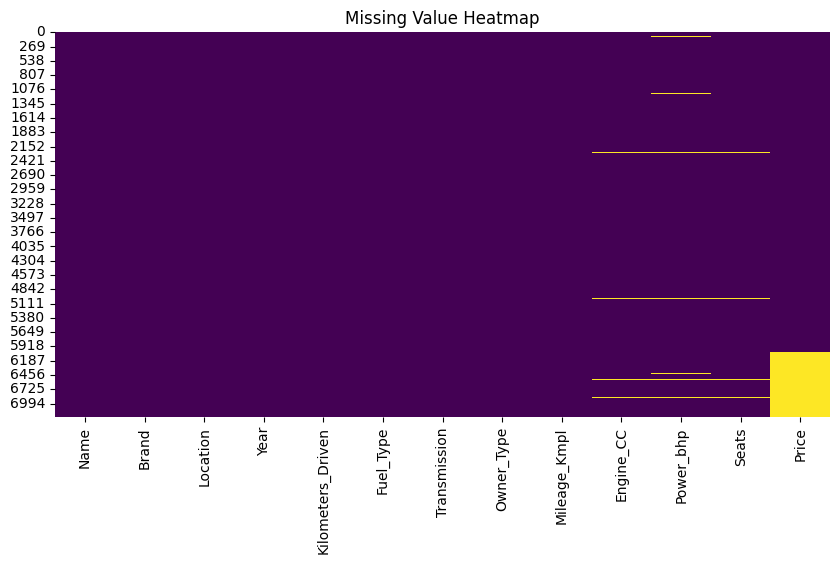

In [72]:
# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(ucd.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

In [73]:
# HANDLING MISSING VALUES
# Drop rows with missing values in Seats, Power_bhp, Engine_CC, and Mileage_Kmpl
ucd.dropna(subset=['Seats', 'Power_bhp', 'Engine_CC', 'Mileage_Kmpl'], inplace=True)

# Fill missing values in Price with median price
ucd['Price'].fillna(ucd['Price'].median(), inplace=True)

# Final dataset shape after handling missing values
print(f"Dataset shape after handling missing values: {ucd.shape}")

Dataset shape after handling missing values: (7073, 13)


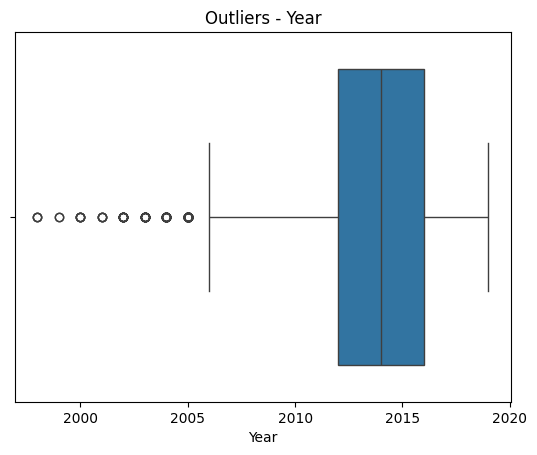

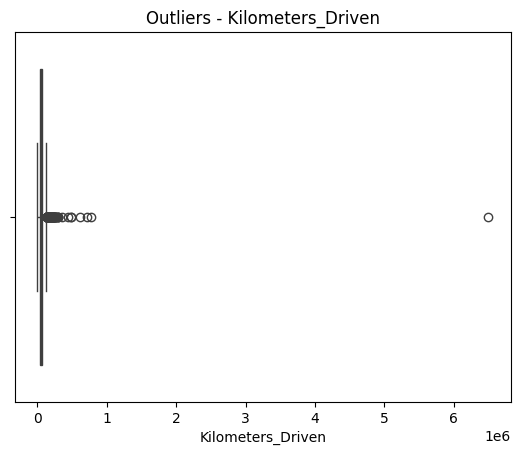

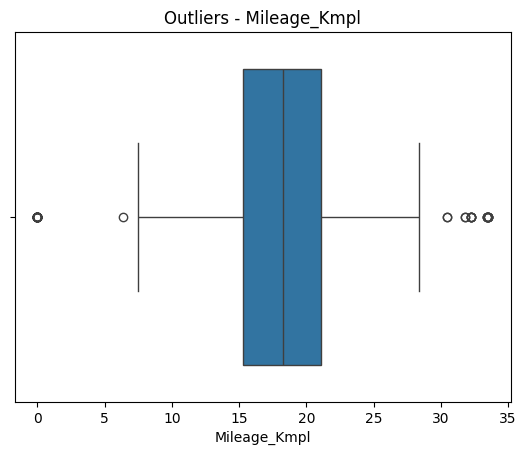

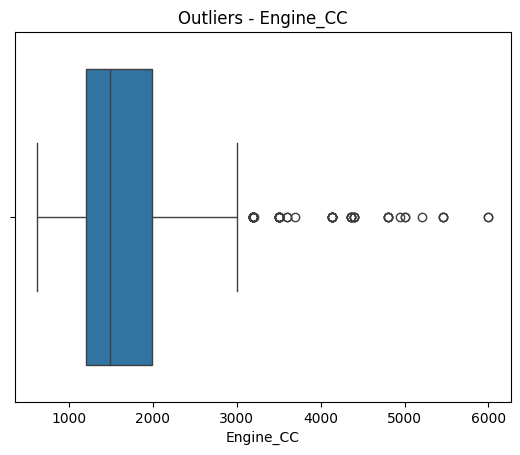

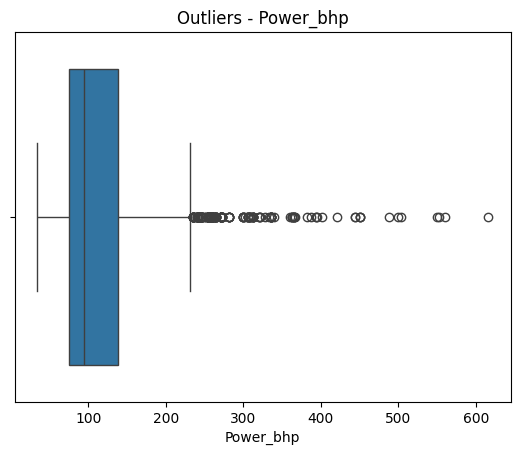

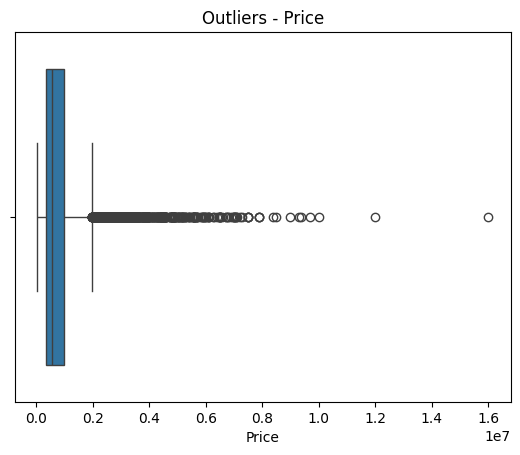

In [ ]:
# OUTLIER HANDLING
numeric_cols = ucd[['Year','Kilometers_Driven','Mileage_Kmpl','Engine_CC','Power_bhp','Price']]
# Boxplot to spot outliers visually in a 2x3 subplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=ucd[col], ax=axes[i])
    axes[i].set_title(f'Outliers - {col}')
plt.tight_layout()
plt.show()

### UNIVARIATE ANALYSIS

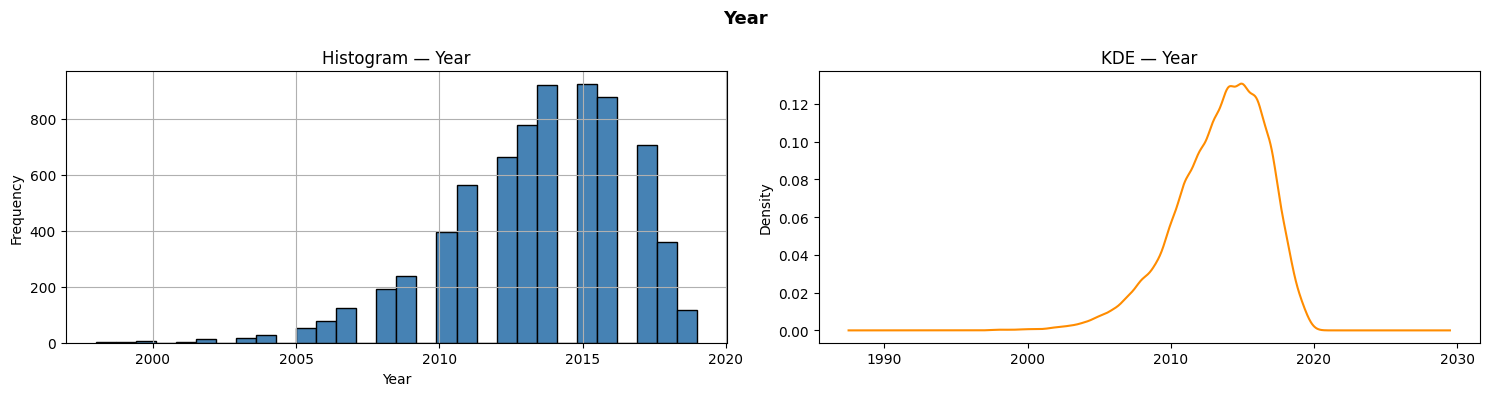


Year
  Mean   : 2013.481
  Median : 2014.000
  Std    : 3.152
  Skew   : -0.801
  Kurt   : 0.822
-----------------------------------


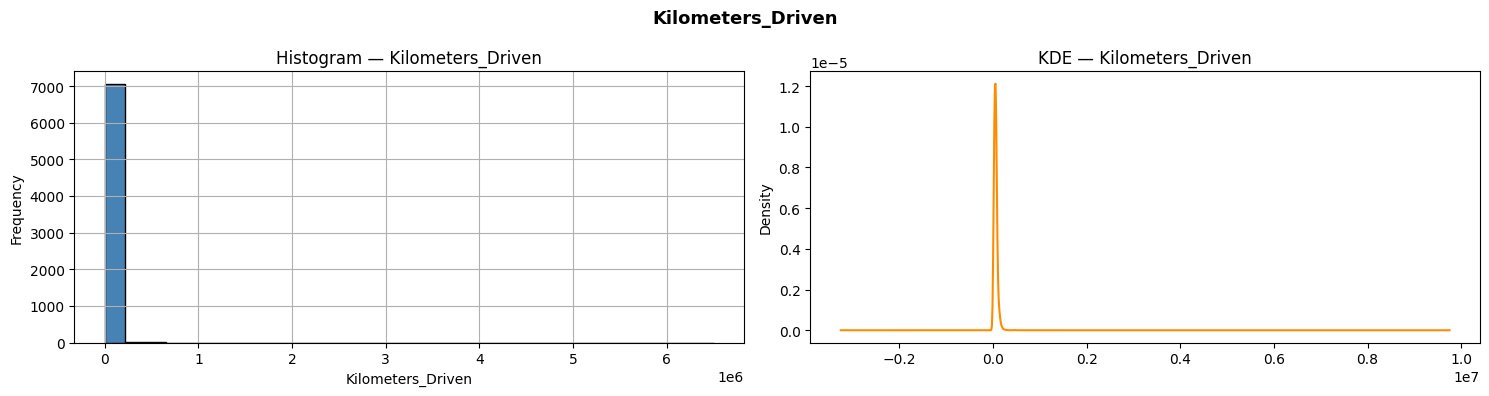


Kilometers_Driven
  Mean   : 58257.333
  Median : 53000.000
  Std    : 85239.455
  Skew   : 61.372
  Kurt   : 4615.028
-----------------------------------


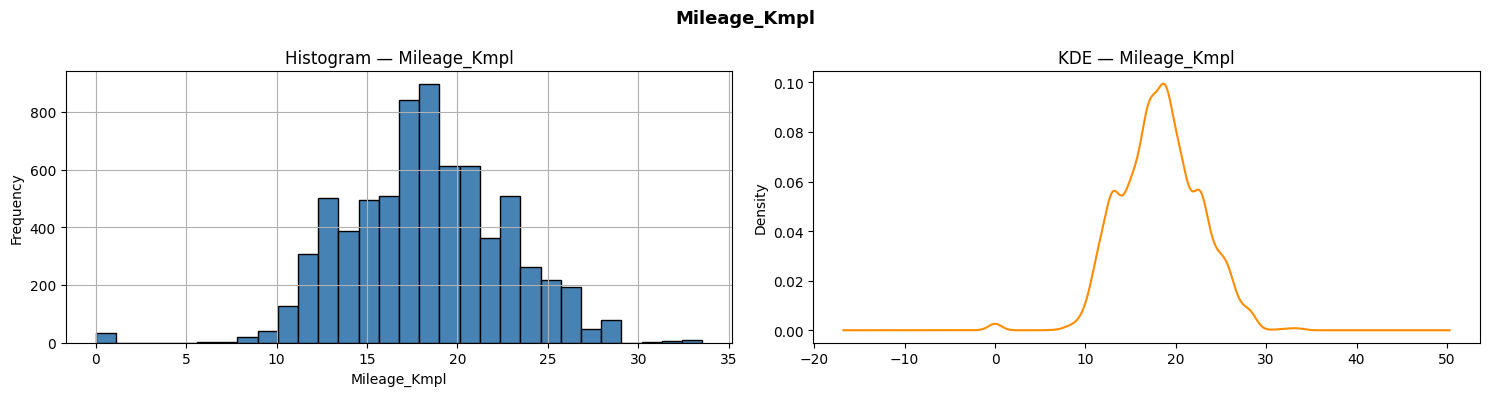


Mileage_Kmpl
  Mean   : 18.279
  Median : 18.250
  Std    : 4.349
  Skew   : -0.124
  Kurt   : 0.797
-----------------------------------


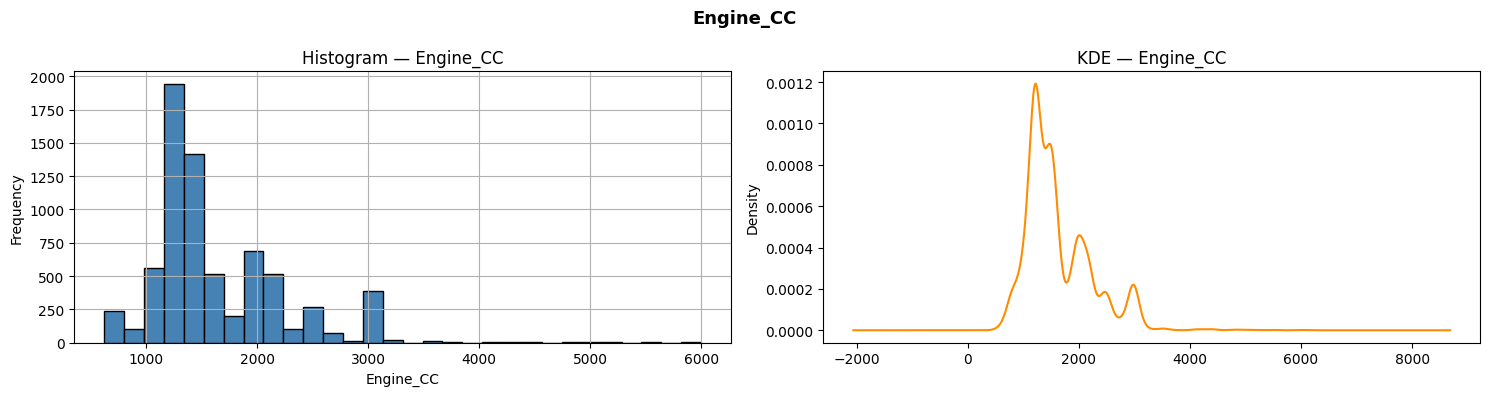


Engine_CC
  Mean   : 1621.007
  Median : 1495.000
  Std    : 595.900
  Skew   : 1.406
  Kurt   : 3.173
-----------------------------------


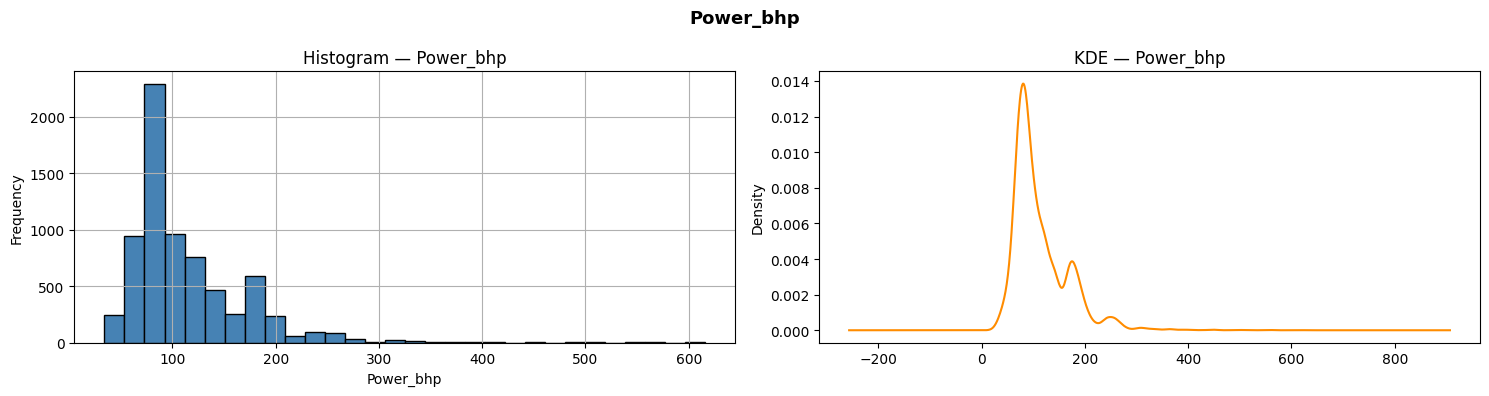


Power_bhp
  Mean   : 112.788
  Median : 94.000
  Std    : 53.502
  Skew   : 1.961
  Kurt   : 7.126
-----------------------------------


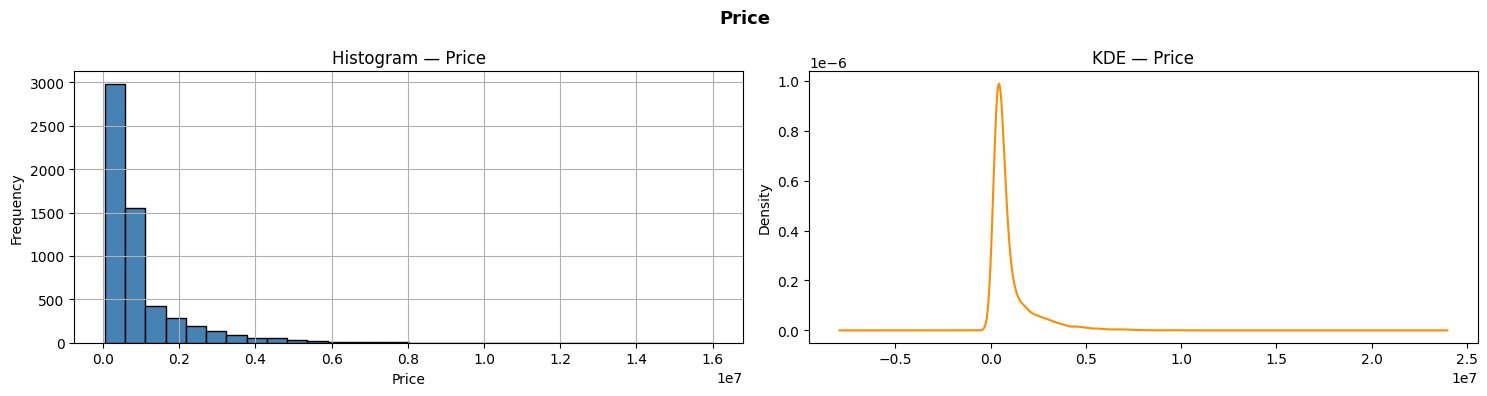


Price
  Mean   : 960391.860
  Median : 575000.000
  Std    : 1124945.322
  Skew   : 3.323
  Kurt   : 16.963
-----------------------------------


In [ ]:
# Numerical Columns Distribution Analysis
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # Histogram
    ucd[col].hist(ax=axes[0], bins=30, color='steelblue', edgecolor='black')
    axes[0].set_title(f'Histogram — {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # KDE
    ucd[col].dropna().plot(kind='kde', ax=axes[1], color='darkorange')
    axes[1].set_title(f'KDE — {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')


    plt.suptitle(col, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


    # Stats
    print(f"\n{col}")
    print(f"  Mean   : {ucd[col].mean():.3f}")
    print(f"  Median : {ucd[col].median():.3f}")
    print(f"  Std    : {ucd[col].std():.3f}")
    print(f"  Skew   : {ucd[col].skew():.3f}")
    print(f"  Kurt   : {ucd[col].kurt():.3f}")
    print("-" * 35)


Brand — 31 unique values
Brand
Maruti           1404
Hyundai          1284
Honda             734
Toyota            481
Mercedes-Benz     378
Volkswagen        373
Ford              342
Mahindra          326
BMW               305
Audi              284
Name: count, dtype: int64


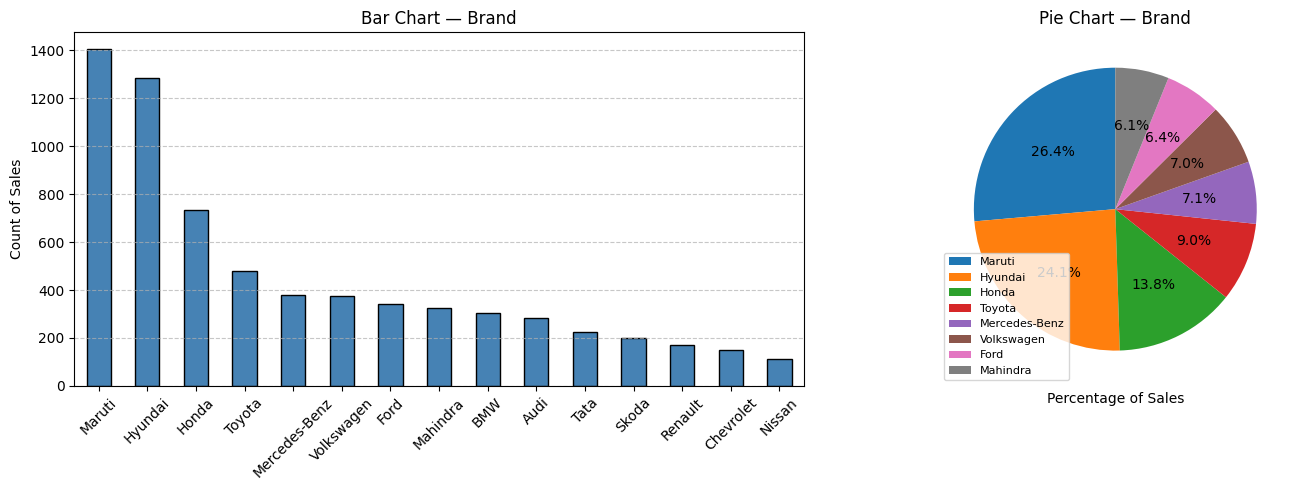


Location — 11 unique values
Location
Mumbai        934
Hyderabad     850
Kochi         764
Coimbatore    762
Pune          734
Delhi         650
Kolkata       633
Chennai       569
Jaipur        484
Bangalore     422
Name: count, dtype: int64


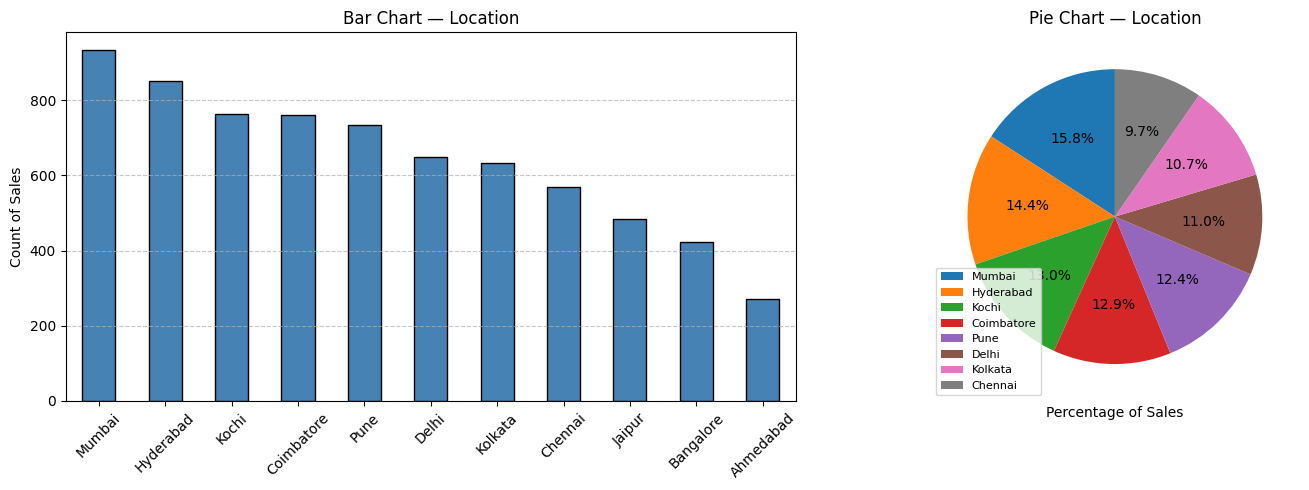


Fuel_Type — 4 unique values
Fuel_Type
Diesel    3783
Petrol    3217
CNG         61
LPG         12
Name: count, dtype: int64


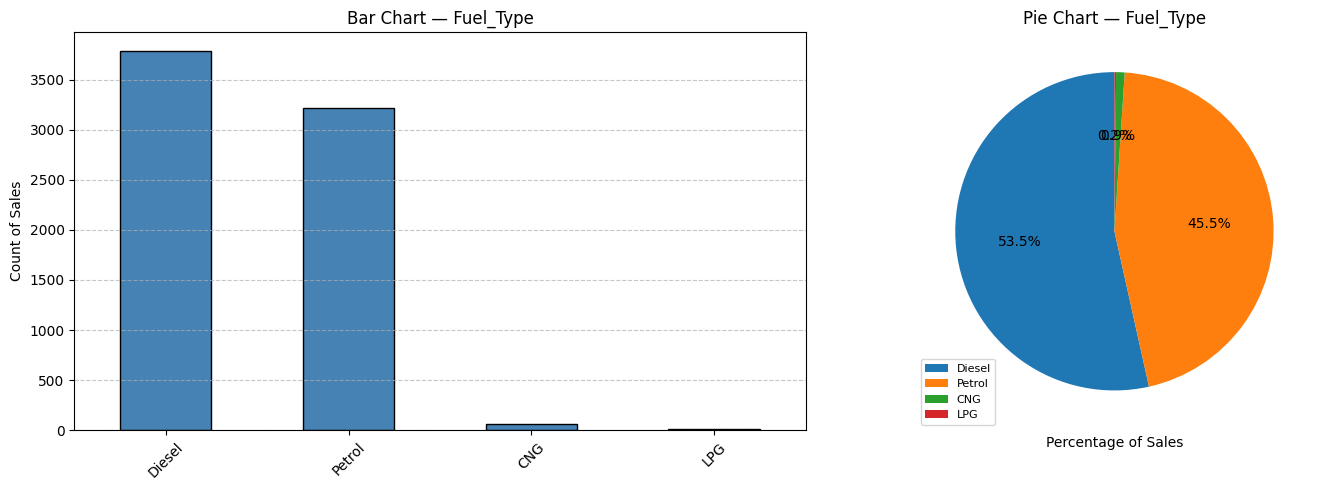


Transmission — 2 unique values
Transmission
Manual       5048
Automatic    2025
Name: count, dtype: int64


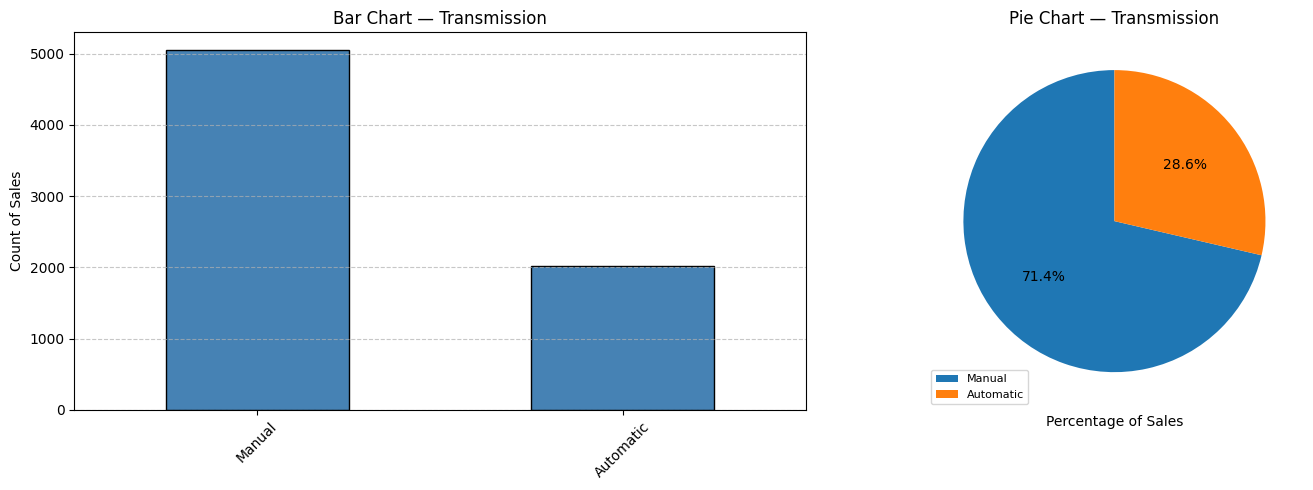


Owner_Type — 4 unique values
Owner_Type
First             5840
Second            1100
Third              124
Fourth & Above       9
Name: count, dtype: int64


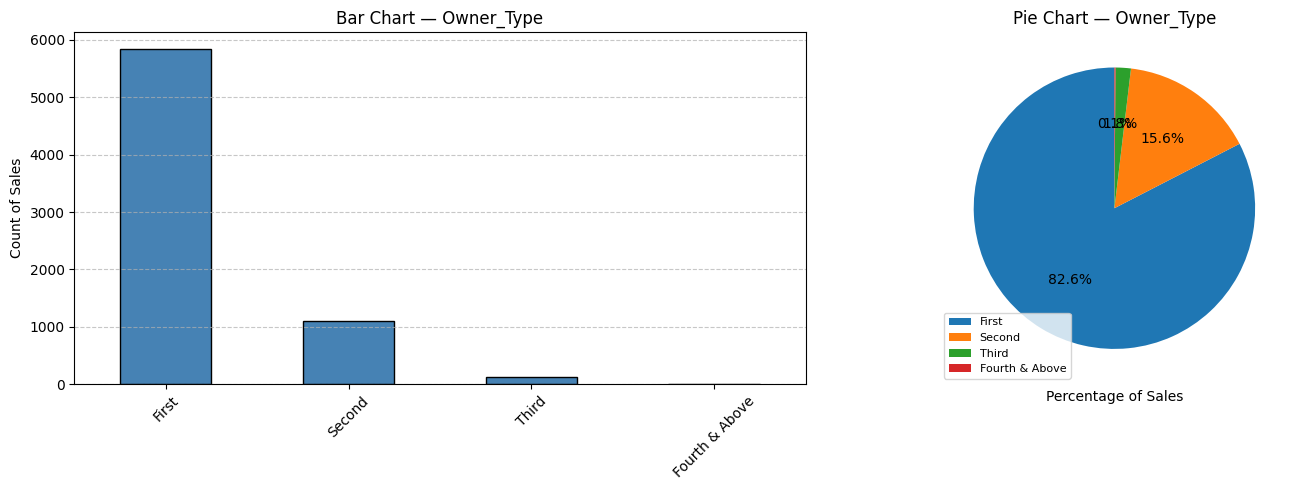


Seats — 8 unique values
Seats
5.0     5930
7.0      794
8.0      169
4.0      119
6.0       36
2.0       15
10.0       7
9.0        3
Name: count, dtype: int64


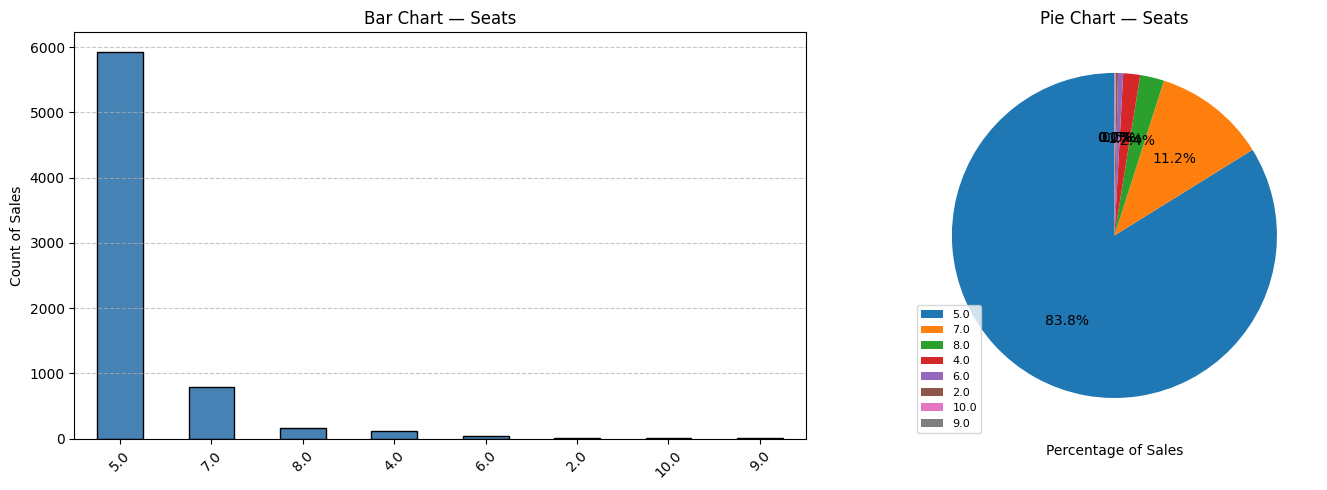

In [101]:
# Categorical Columns Analysis
categorical_cols = ucd[['Brand','Location','Fuel_Type','Transmission','Owner_Type','Seats']]
for col in categorical_cols:
    n_unique = ucd[col].nunique()
    print(f"\n{col} — {n_unique} unique values")
    print(ucd[col].value_counts().head(10))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Bar chart (top 15)
    ucd[col].value_counts().head(15).plot(
        kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
    )
    axes[0].set_title(f'Bar Chart — {col}')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_ylabel('Count of Sales')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Pie chart (top 8)
    ucd[col].value_counts().head(8).plot(
        kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90, labels=None
    )
    axes[1].set_xlabel('Percentage of Sales')
    axes[1].set_title(f'Pie Chart — {col}')
    axes[1].legend(ucd[col].value_counts().head(8).index, loc='lower left', fontsize=8)


    plt.tight_layout()
    plt.show()

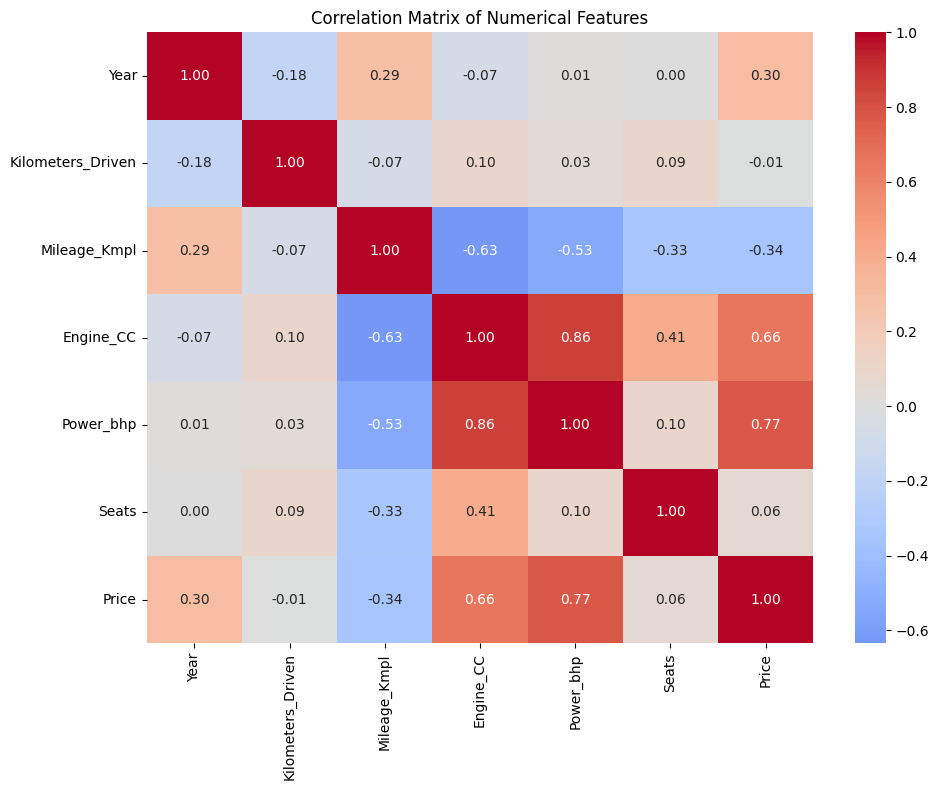


Highest Correlations with Numeric Columns:
Year               Year                 1.000000
Kilometers_Driven  Kilometers_Driven    1.000000
Mileage_Kmpl       Mileage_Kmpl         1.000000
Power_bhp          Power_bhp            1.000000
Engine_CC          Engine_CC            1.000000
Seats              Seats                1.000000
Price              Price                1.000000
Power_bhp          Engine_CC            0.859864
Engine_CC          Power_bhp            0.859864
Price              Power_bhp            0.772843
dtype: float64


In [76]:
# Correlation Analysis
numeric_data = ucd.select_dtypes(include=[np.number])
if len(numeric_data.columns) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Matrix of Numerical Features')
    plt.tight_layout()
    plt.show()
    
print("\nHighest Correlations with Numeric Columns:")
print(numeric_data.corr().abs().unstack().sort_values(ascending=False).head(10))

In [77]:
# Outlier Detection (IQR Method)
print("Outlier Detection (IQR Method):")
for col in numeric_cols:
    Q1 = ucd[col].quantile(0.25)
    Q3 = ucd[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ucd[(ucd[col] < lower_bound) | (ucd[col] > upper_bound)]
    if len(outliers) > 0:
        print(f"\n{col}: {len(outliers)} outliers ({len(outliers)/len(ucd)*100:.2f}%)")
        
# Data Quality Summary
print("\n" + "="*50)
print("DATA QUALITY SUMMARY")
print("="*50)
print(f"Total Records: {len(ucd)}")
print(f"Total Features: {len(ucd.columns)}")
print(f"Duplicate Rows: {ucd.duplicated().sum()}")

Outlier Detection (IQR Method):

Year: 125 outliers (1.77%)

Kilometers_Driven: 245 outliers (3.46%)

Mileage_Kmpl: 53 outliers (0.75%)

Engine_CC: 62 outliers (0.88%)

Power_bhp: 273 outliers (3.86%)

Seats: 1143 outliers (16.16%)

Price: 712 outliers (10.07%)

DATA QUALITY SUMMARY
Total Records: 7073
Total Features: 13
Duplicate Rows: 1


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
